# Dataset-overparametrized regime (P > N)

The R1 crux: trace best training loss across the P/N=1 boundary by subsampling the training set. Sven's edge should be specific to P>N. Datasets carry `n_data`; P is fixed per model.

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import add_derived, best_per_method, valid, loss_curve, steps_to_target, method_order
from pathlib import Path
set_style()
PLOT_DIR = Path('plots/overparam'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
def sven_color(m): return 'k' if m=='Sven' else None
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
SCANS = {'toy_1d': ('rebuttal_overparam_toy_1d_scan', 593),
         'polynomial': ('rebuttal_overparam_polynomial_scan', 673),
         'mnist': ('rebuttal_overparam_mnist_scan', 27562)}
data = {}
for tag,(name,P) in SCANS.items():
    try:
        df = add_derived(load_results(name)); df['P']=P
        data[tag]=df
    except FileNotFoundError:
        print('missing', name)

Loaded 1660 runs from ../experiment_results/rebuttal_overparam_toy_1d_scan/ (directory format, slim)
Loaded 1660 runs from ../experiment_results/rebuttal_overparam_polynomial_scan/ (directory format, slim)
Loaded 2136 runs from ../experiment_results/rebuttal_overparam_mnist_scan/ (directory format, slim)


### Best train loss vs P/N, per optimizer (log-log). Sven in black.

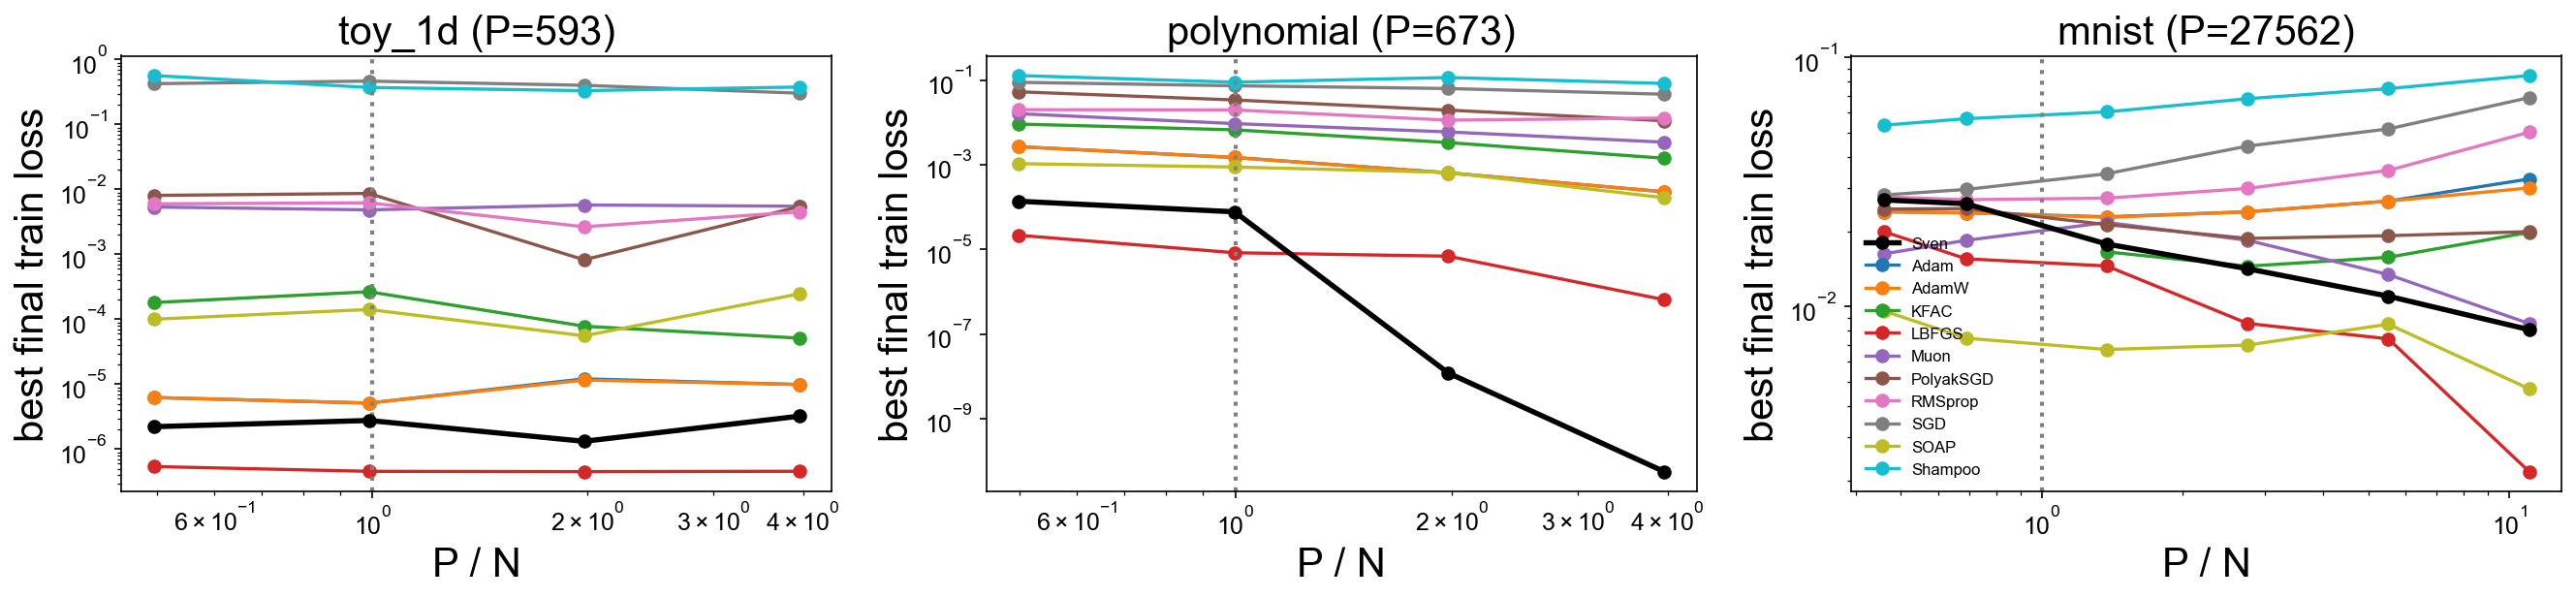

In [3]:
fig, axes = plt.subplots(1, len(data), figsize=(6*len(data),4.4), squeeze=False)
for ax,(tag,df) in zip(axes[0], data.items()):
    P = df['P'].iloc[0]
    b = best_per_method(df, by='final_train_loss', extra_group=['n_data'])
    for m in method_order(b['method'].unique()):
        s = b[b.method==m].sort_values('n_data')
        ax.plot(P/s['n_data'], s['final_train_loss'], marker='o', color=sven_color(m),
                lw=sven_lw(m), label=m, zorder=3 if m=='Sven' else 1)
    ax.axvline(1.0, ls=':', c='gray'); ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'{tag} (P={P})'); ax.set_xlabel('P / N'); ax.set_ylabel('best final train loss')
axes[0][-1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'best_trainloss_vs_PoverN.pdf', bbox_inches='tight'); plt.show()

### Sven's rank across the crossover

In [4]:
for tag,df in data.items():
    P=df['P'].iloc[0]; print(f'== {tag} (P={P}) ==')
    b=best_per_method(df, by='final_train_loss', extra_group=['n_data'])
    for nd in sorted(b['n_data'].unique()):
        sub=b[b.n_data==nd].sort_values('final_train_loss').reset_index(drop=True)
        rank=sub.index[sub.method=='Sven'].tolist()
        r=rank[0]+1 if rank else '-'
        print(f'  N={nd:<6} P/N={P/nd:5.2f}  Sven rank {r}/{len(sub)}  (best={sub.method.iloc[0]})')

== toy_1d (P=593) ==
  N=150    P/N= 3.95  Sven rank 2/11  (best=LBFGS)
  N=300    P/N= 1.98  Sven rank 2/11  (best=LBFGS)
  N=600    P/N= 0.99  Sven rank 2/11  (best=LBFGS)
  N=1200   P/N= 0.49  Sven rank 2/11  (best=LBFGS)
== polynomial (P=673) ==
  N=170    P/N= 3.96  Sven rank 1/11  (best=Sven)
  N=340    P/N= 1.98  Sven rank 1/11  (best=Sven)
  N=675    P/N= 1.00  Sven rank 2/11  (best=LBFGS)
  N=1350   P/N= 0.50  Sven rank 2/11  (best=LBFGS)
== mnist (P=27562) ==
  N=2500   P/N=11.02  Sven rank 3/11  (best=LBFGS)
  N=5000   P/N= 5.51  Sven rank 3/11  (best=LBFGS)
  N=10000  P/N= 2.76  Sven rank 3/11  (best=SOAP)
  N=20000  P/N= 1.38  Sven rank 4/11  (best=SOAP)
  N=40000  P/N= 0.69  Sven rank 7/10  (best=SOAP)
  N=60000  P/N= 0.46  Sven rank 7/10  (best=SOAP)
